In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Ai/disease_prediction.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [ ]:
df.isna().sum()

,0
patient_id,0
age,0
gender,0
glucose_mg_dl,0
cholesterol_mg_dl,0
systolic_bp,0
diastolic_bp,0
bmi,0
heart_rate,0
smoking,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
n=df.select_dtypes(include=['object'])
for col in n.columns:
  df[col]=le.fit_transform(df[col])

df

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,1,101,235,152,79,28.5,73,0,1,1,1,1
1,2,31,1,124,191,134,77,33.9,71,0,1,1,1,1
2,3,45,1,57,141,114,71,27.2,79,1,1,1,0,0
3,4,75,0,69,268,120,82,21.5,61,1,1,2,0,1
4,5,53,1,107,163,131,75,23.3,73,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,24,1,105,237,86,86,30.9,69,1,1,2,0,0
996,997,40,1,120,219,133,72,34.3,92,1,1,2,0,0
997,998,44,0,114,273,114,74,36.0,76,0,0,1,0,1
998,999,31,1,95,231,130,72,28.2,81,1,1,2,1,0


/tmp/ipykernel_2452/160573771.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(n.values,labels=n.columns)


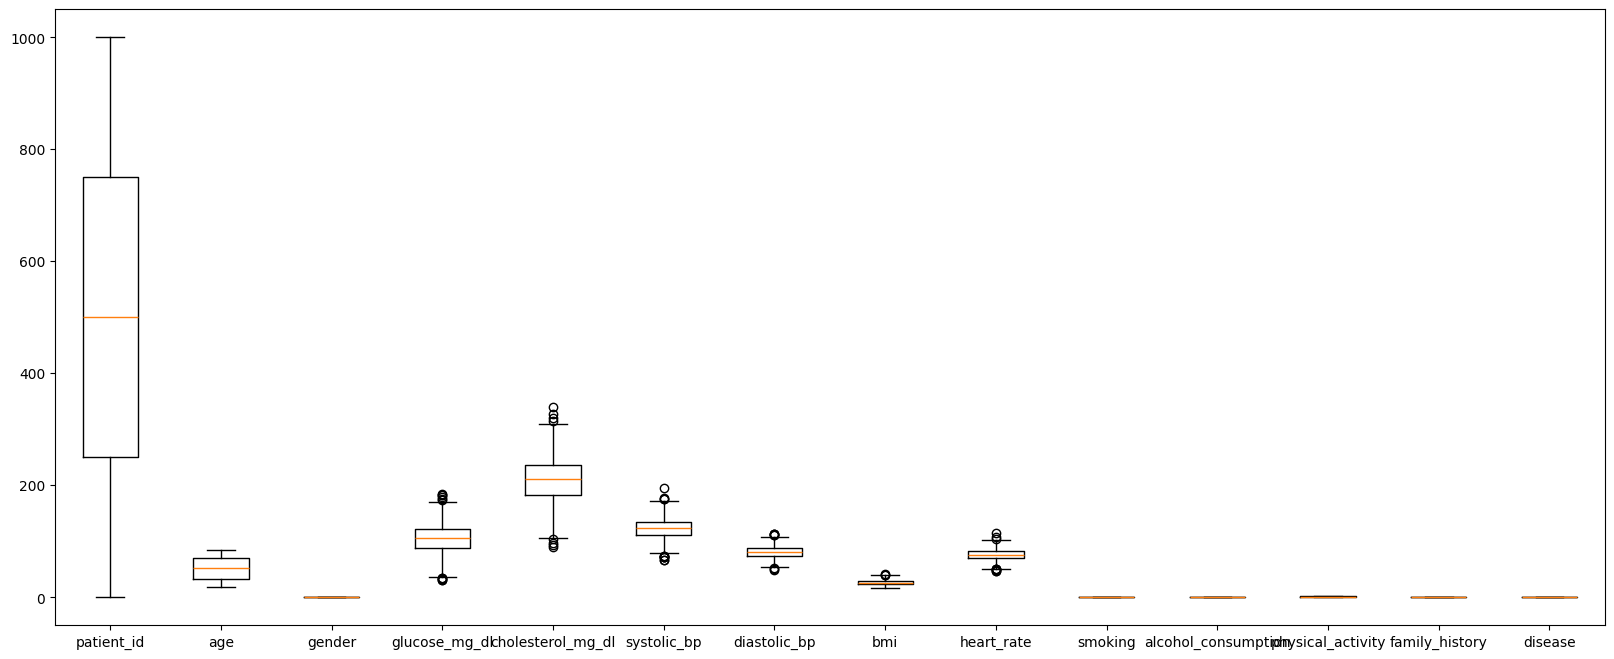

In [ ]:
n=df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(20,8))
plt.boxplot(n.values,labels=n.columns)
plt.show()

In [ ]:
n=df.select_dtypes(include=['float64','int64']).columns
for col in n:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  df[col]=df[col].clip(lower,upper)
df

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,1,101,235.0,152,79,28.5,73.0,0,1,1,1,1
1,2,31,1,124,191.0,134,77,33.9,71.0,0,1,1,1,1
2,3,45,1,57,141.0,114,71,27.2,79.0,1,1,1,0,0
3,4,75,0,69,268.0,120,82,21.5,61.0,1,1,2,0,1
4,5,53,1,107,163.0,131,75,23.3,73.0,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,24,1,105,237.0,86,86,30.9,69.0,1,1,2,0,0
996,997,40,1,120,219.0,133,72,34.3,92.0,1,1,2,0,0
997,998,44,0,114,273.0,114,74,36.0,76.0,0,0,1,0,1
998,999,31,1,95,231.0,130,72,28.2,81.0,1,1,2,1,0


/tmp/ipykernel_2452/160573771.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(n.values,labels=n.columns)


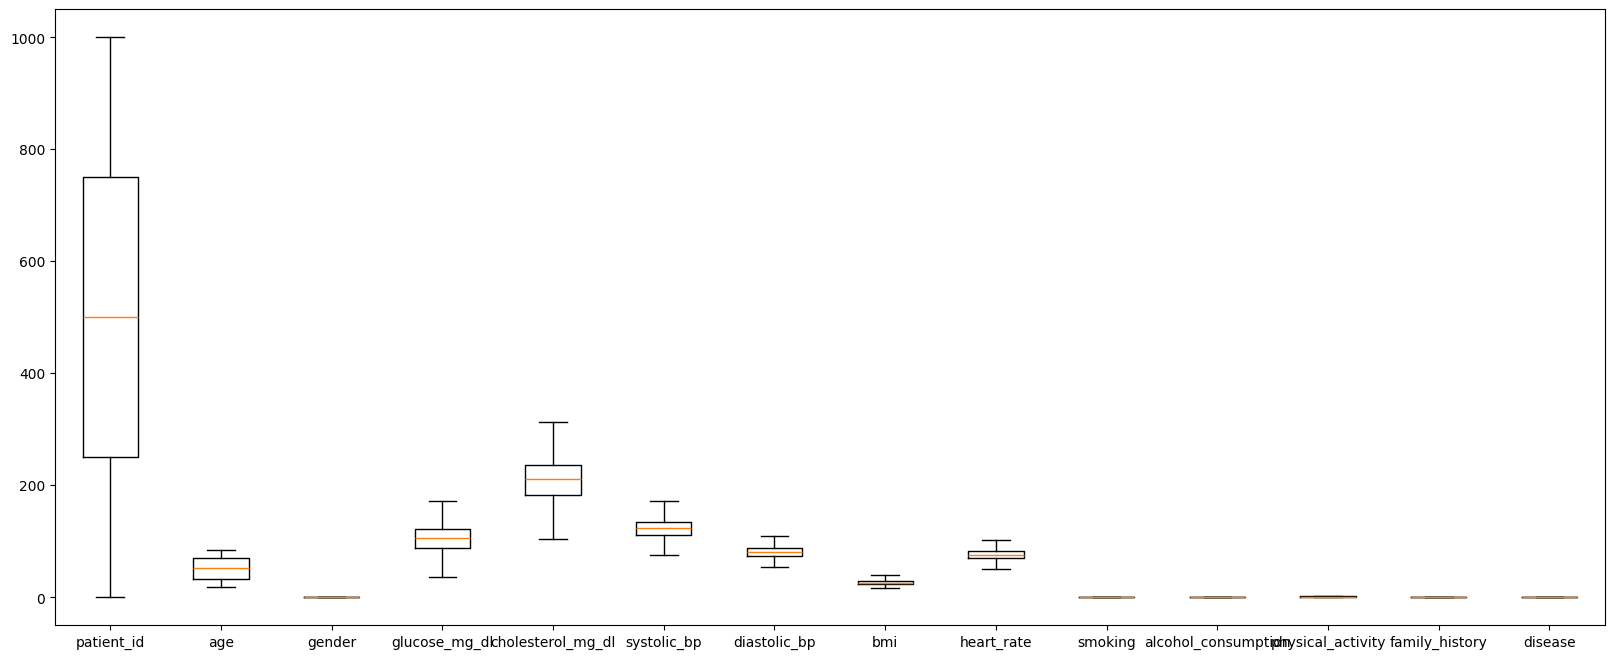

In [ ]:
n=df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(20,8))
plt.boxplot(n.values,labels=n.columns)
plt.show()

In [ ]:
X = df.drop(['patient_id', 'disease'], axis=1)
y = df['disease']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


Accuracy: 0.775


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)


Confusion Matrix
[[86 19]
 [26 69]]


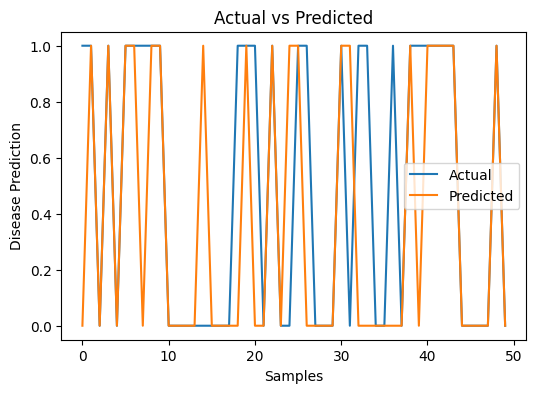

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')

plt.title("Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Disease Prediction")

plt.legend()

plt.show()